**Customer Churn Prediction using Ensemble Learning**

Customer churn is a major challenge faced by subscription based and service based businesses. The goal of this project is to build machine learning models that can predict whether a customer is likely to churn, allowing the business to take proactive retention measures.

This project begins by training individual classification algorithms including Logistic Regression, KNN, Decision Tree, SVM, and Random Forest. These models are then compared against ensemble techniques such as Voting, Bagging, AdaBoost, Gradient Boosting, and Stacking to evaluate how much ensemble methods improve performance over single models.

In [339]:
#Step 1
#Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [340]:
#Step 2
#Load Dataset
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [341]:
#Step 3
#Shape
df.shape

(7043, 21)

In [342]:
#Step 4
#Information of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [343]:
#Step 5
#Missing Values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [344]:
#Step 6
#Duplicates
df.duplicated().sum()

np.int64(0)

In [345]:
#Step 7
#Statistical Summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [346]:
#Step 8
#Target col
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


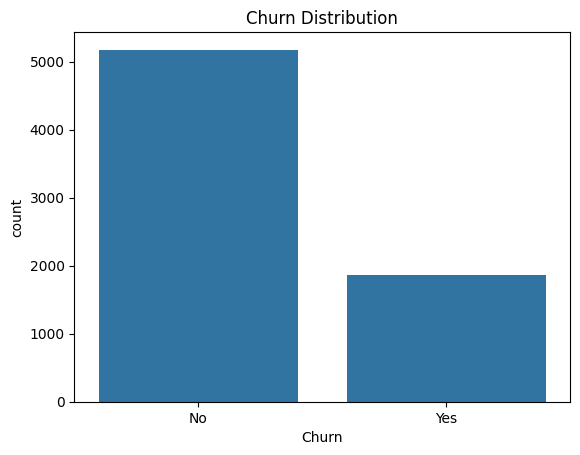

In [347]:
#Step 9
#Distribution
sns.countplot(x="Churn",data=df)
plt.title("Churn Distribution")
plt.show()

In [348]:
#Step 10
#Separate Numerical and Categorical Features

# Fix TotalCharges type first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Impute NaN values in TotalCharges with the mean
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

numerical_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

numerical_features.remove('SeniorCitizen')
categorical_features.append('SeniorCitizen')

print("numerical_features", numerical_features)
print("categorical_features", categorical_features)

numerical_features ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']


In [349]:
#Step 11
#Drop unnecessary Col
df.drop("customerID",axis=1,inplace=True)

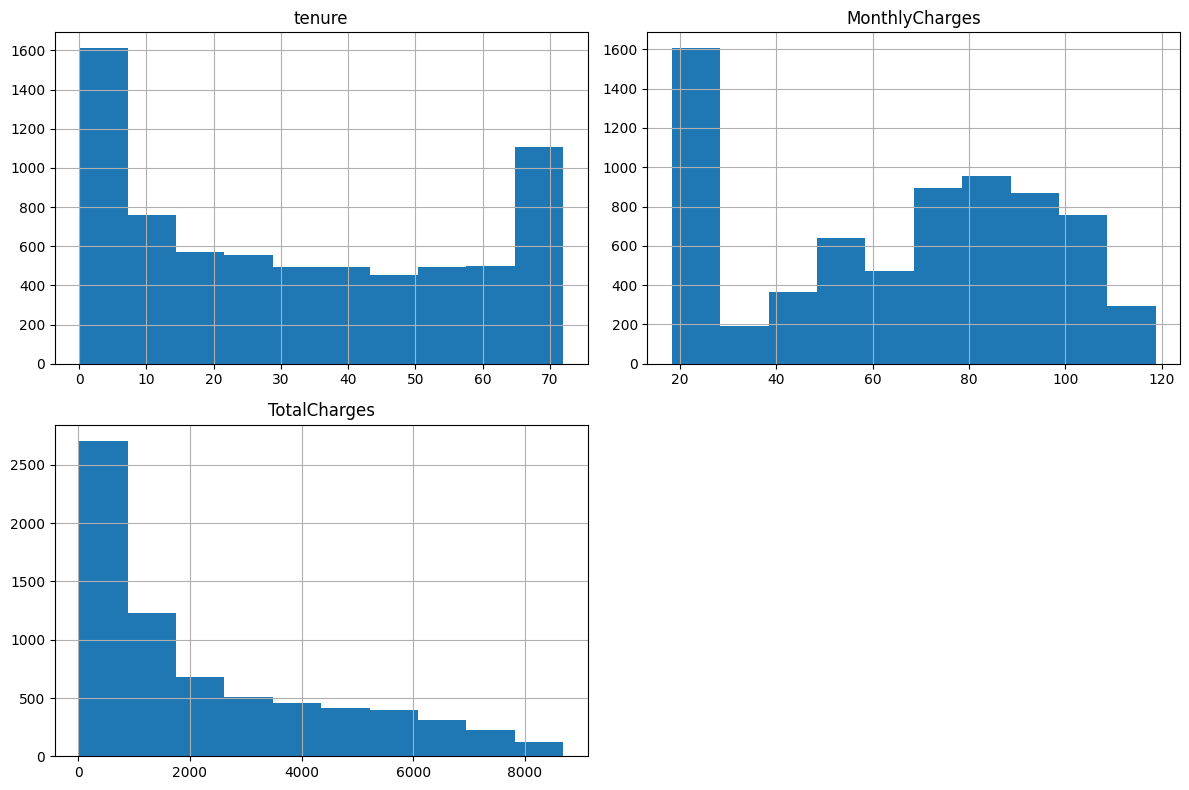

In [350]:
#Step 12
#Numerical Features Distribution
df[numerical_features].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

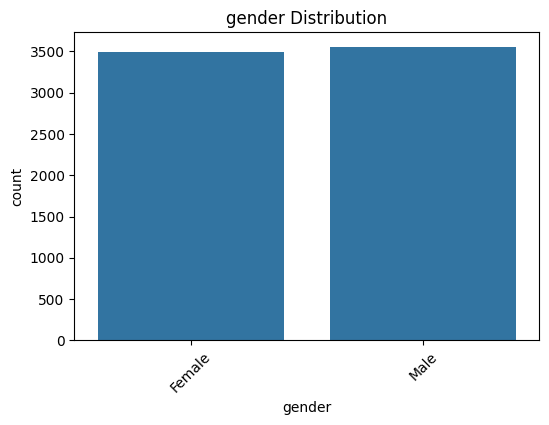

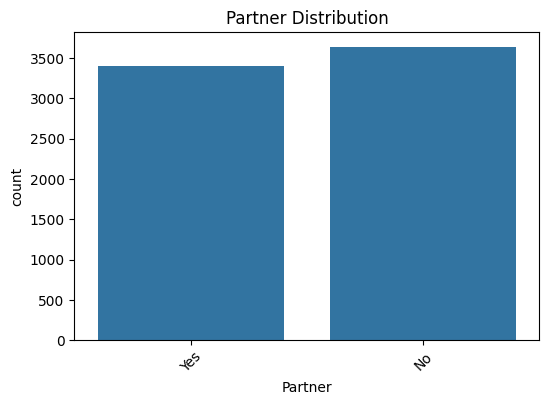

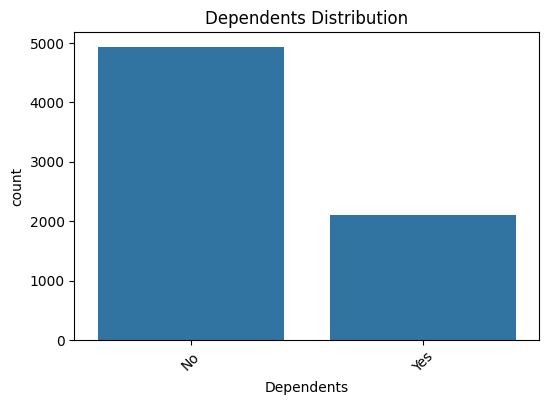

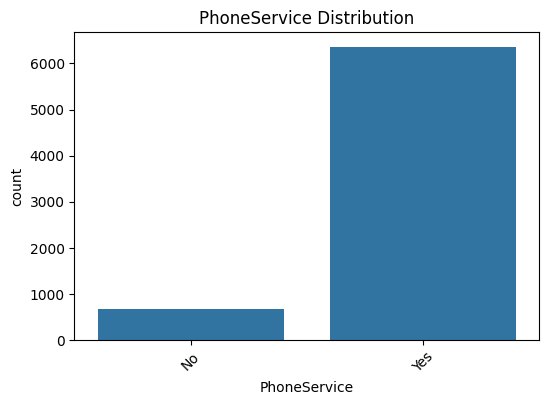

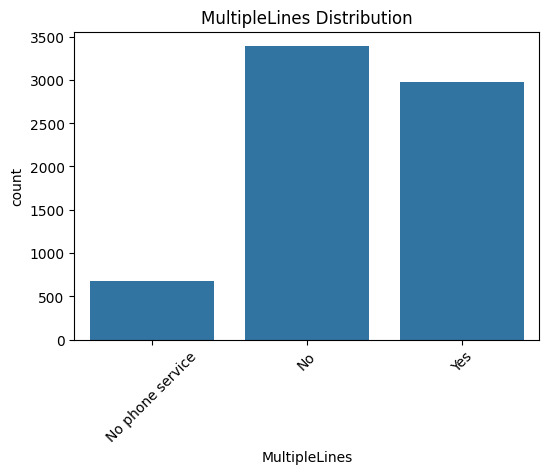

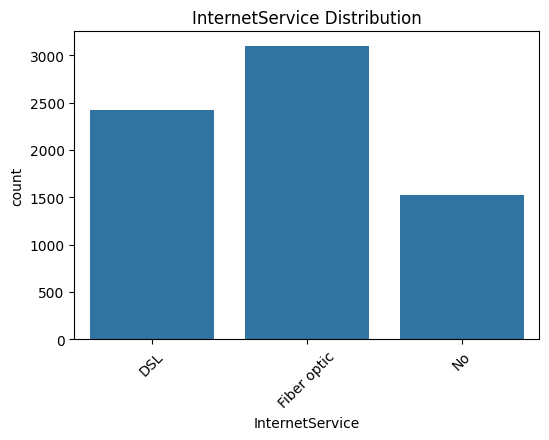

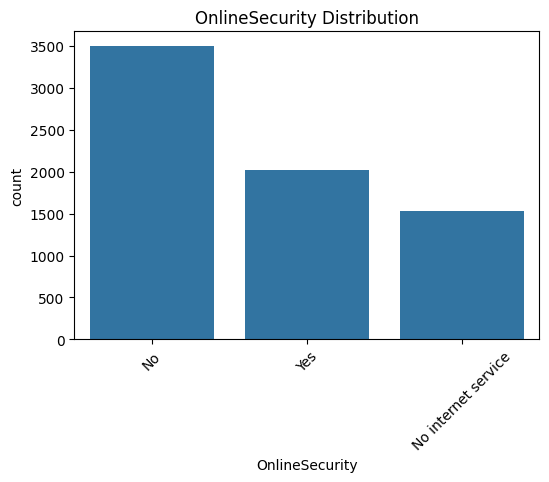

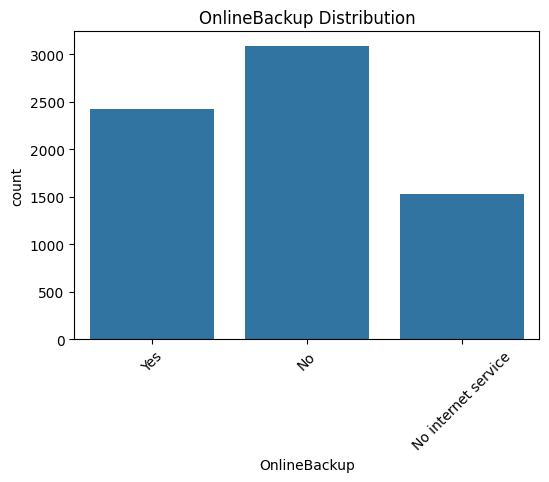

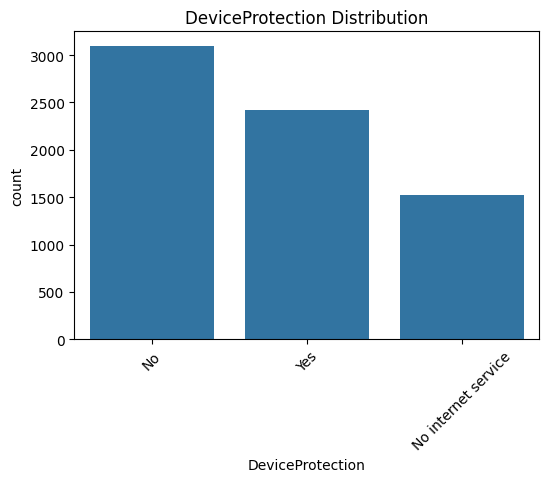

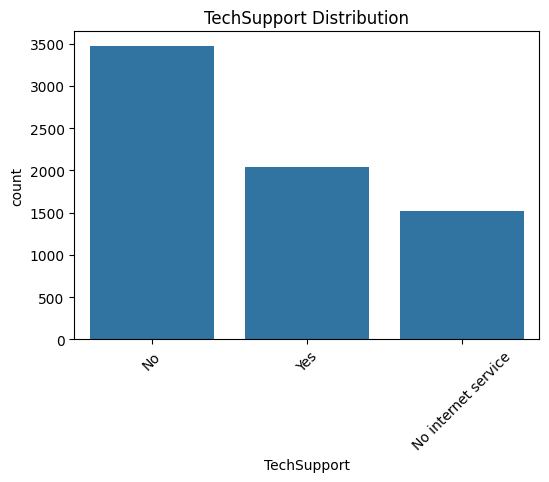

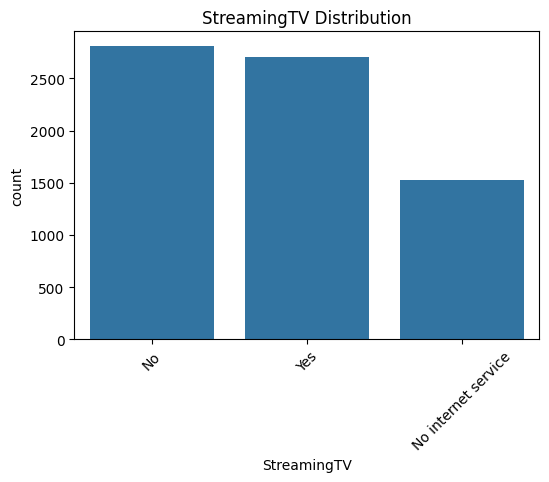

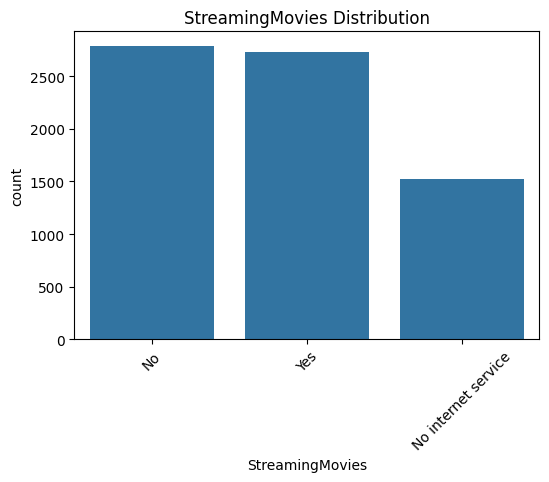

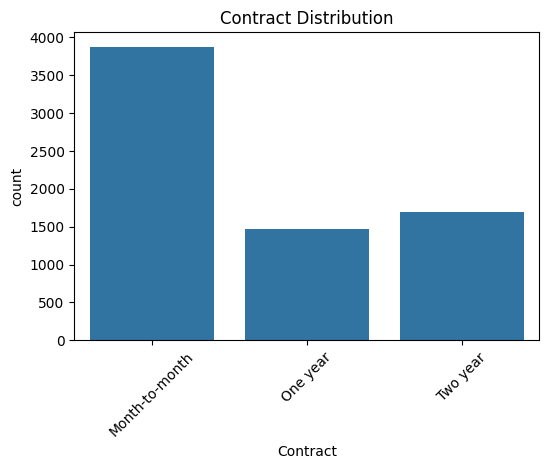

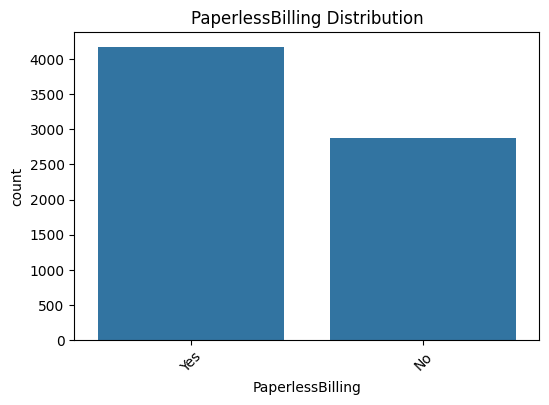

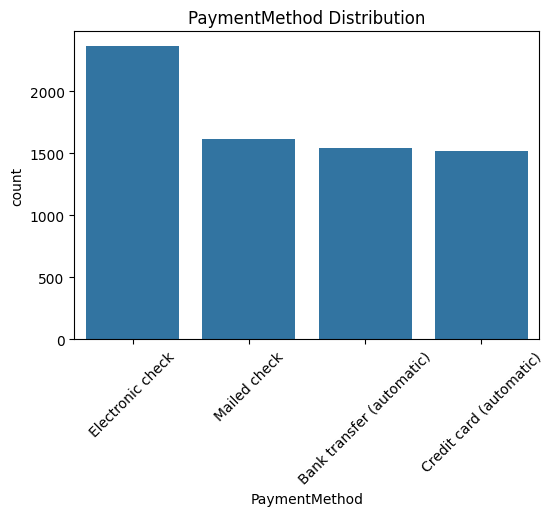

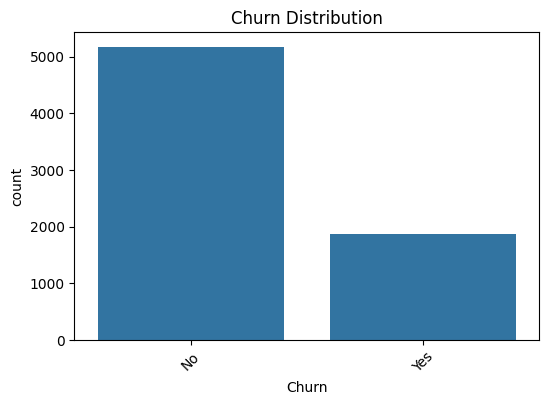

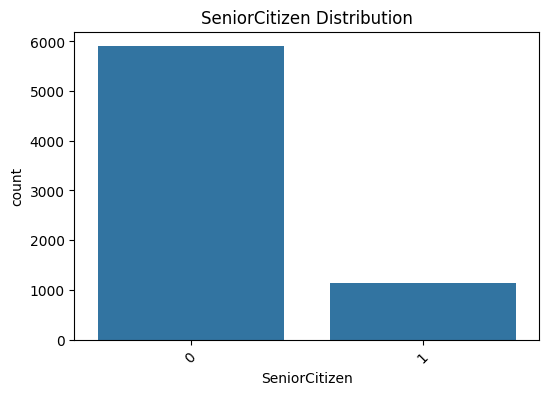

In [351]:
#Step 13
#For Categorical Features
categorical_features = [col for col in categorical_features if col in df.columns]
for col in categorical_features:
  plt.figure(figsize=(6,4))
  sns.countplot(x=col,data=df)
  plt.title(f'{col} Distribution')
  plt.xticks(rotation=45)
  plt.show()

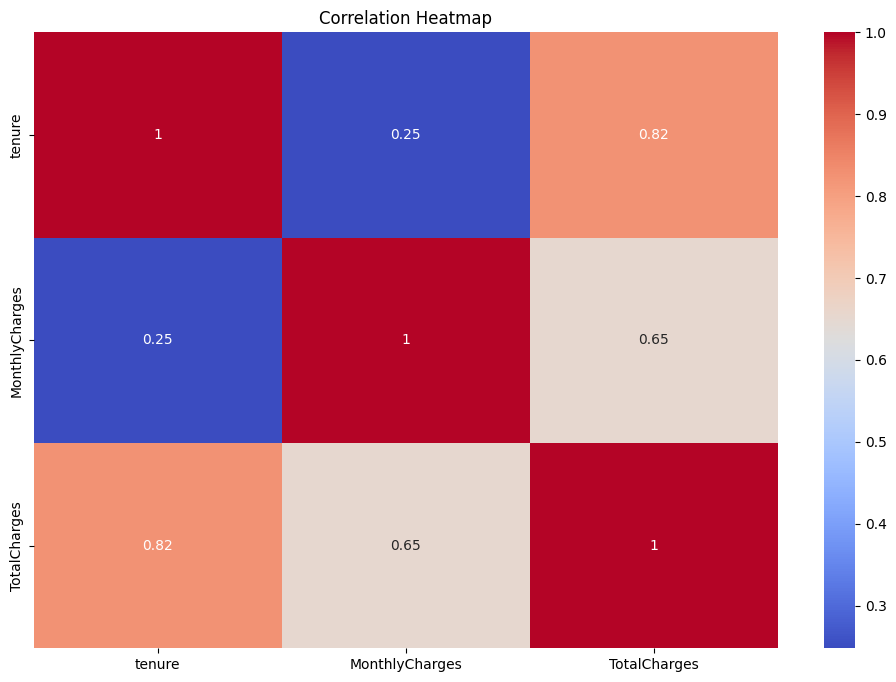

In [352]:
#Step 14
#Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

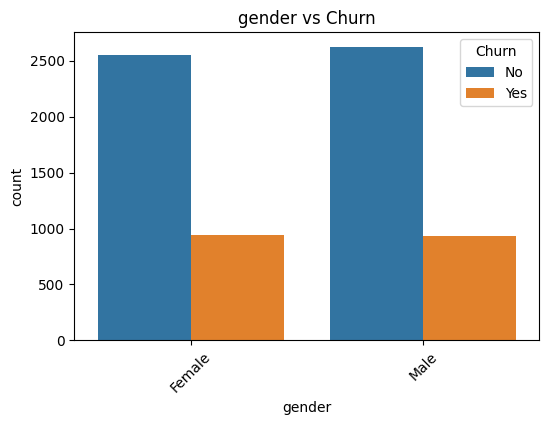

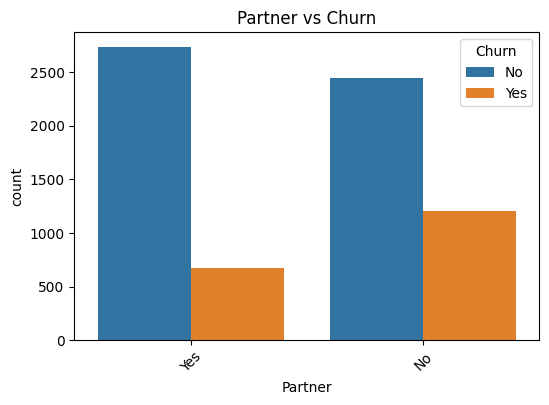

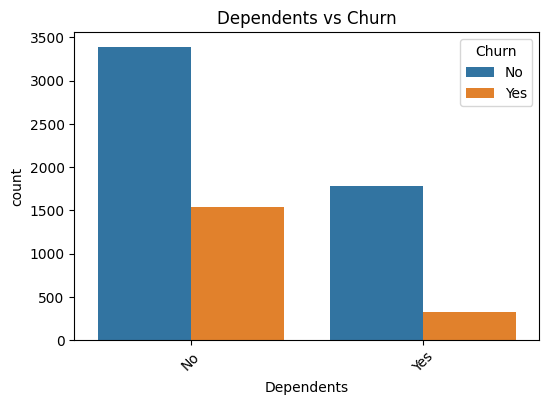

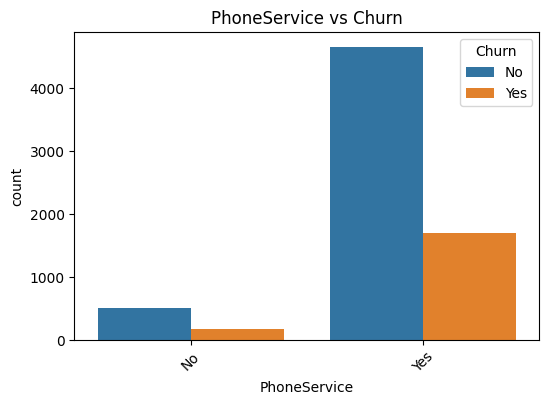

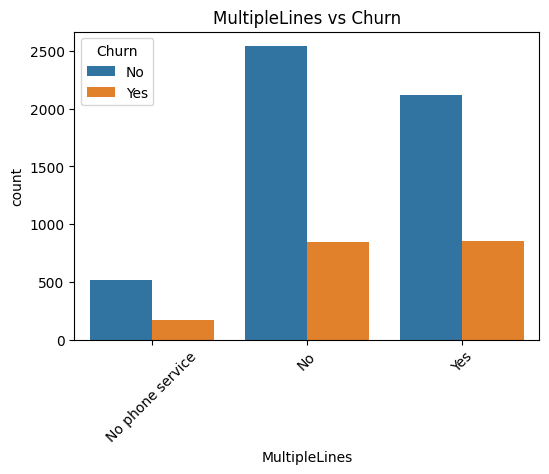

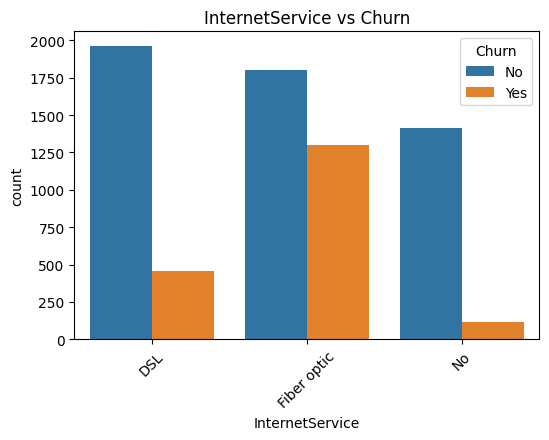

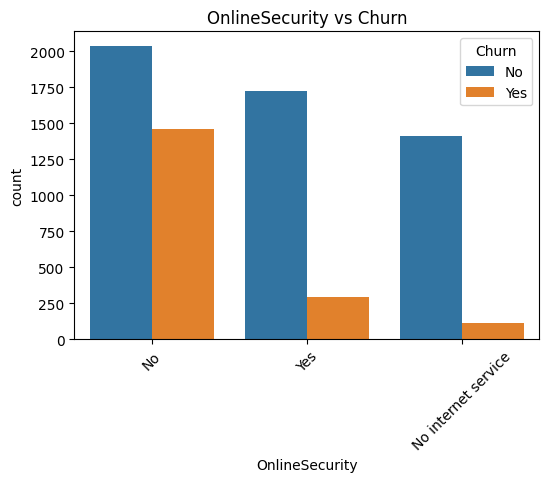

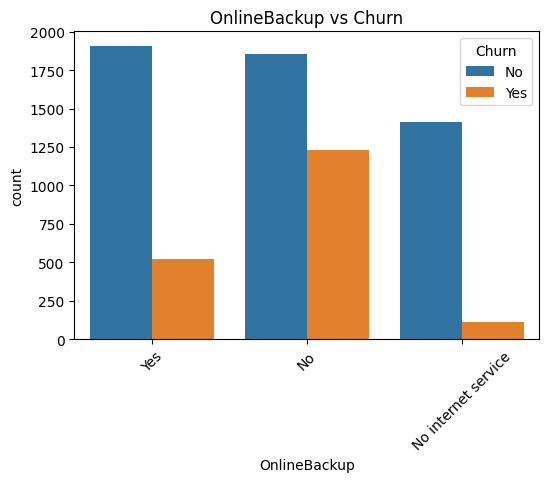

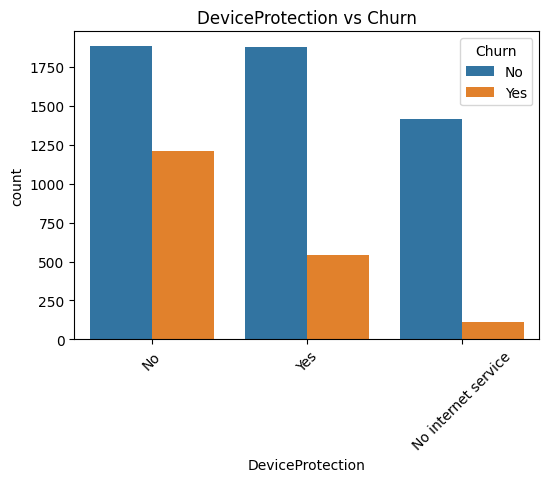

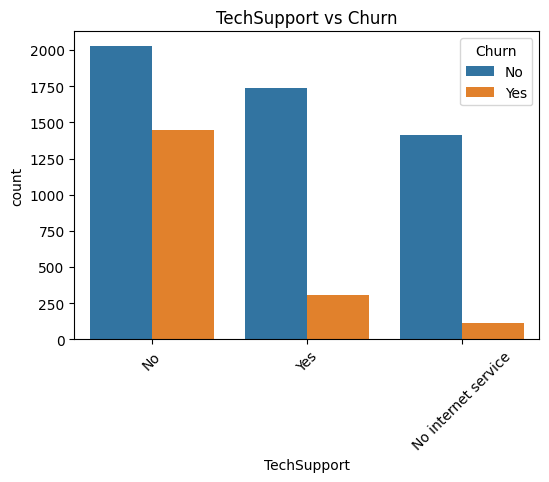

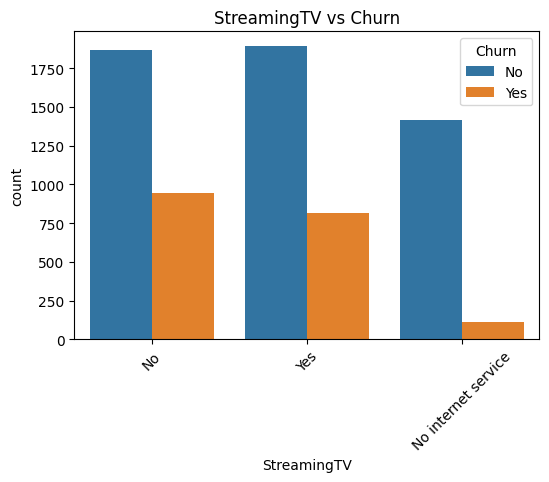

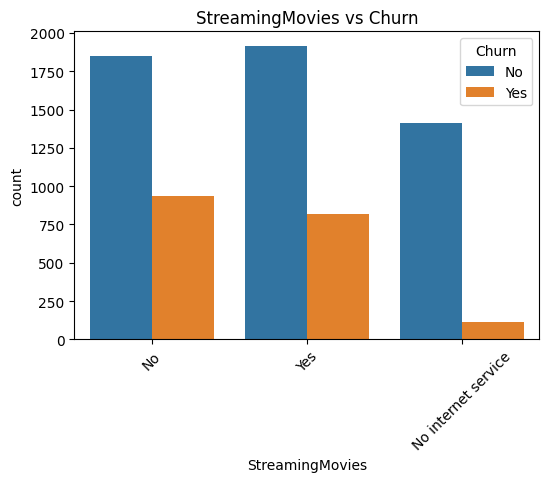

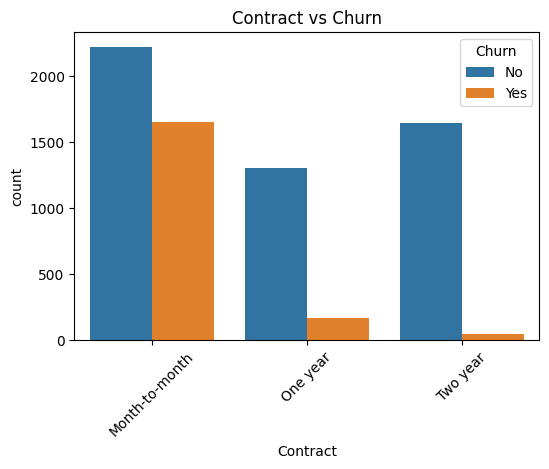

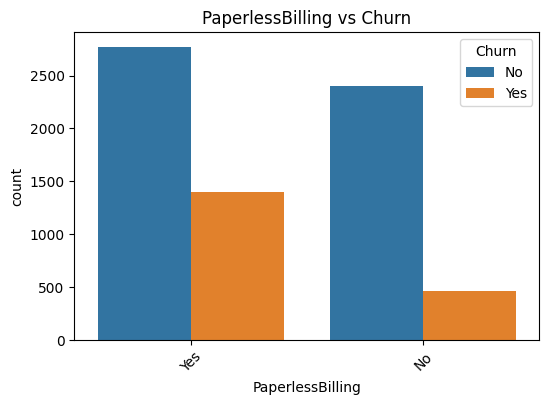

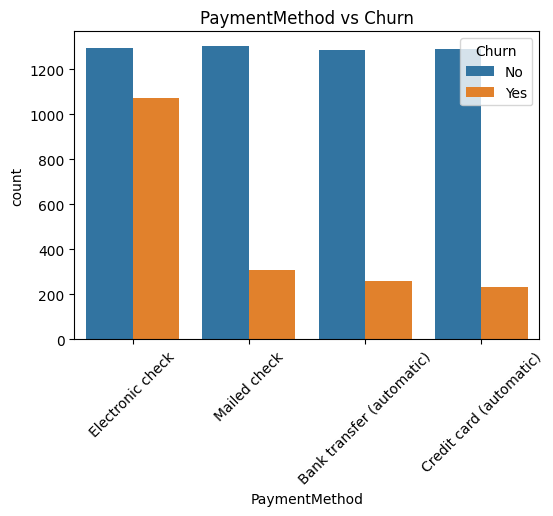

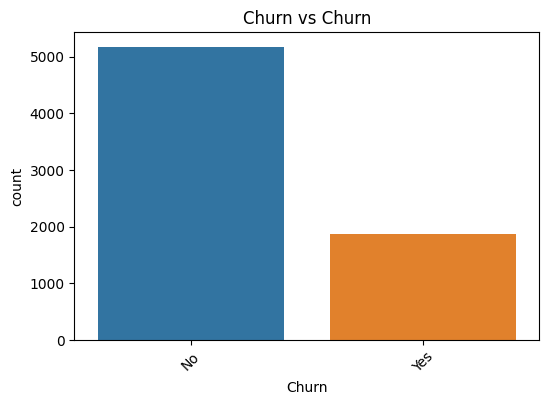

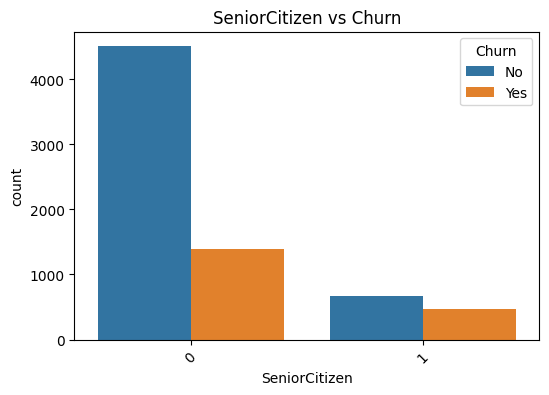

In [353]:
#Step 15
# Categorical features vs Churn
for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Churn", data=df)
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.show()

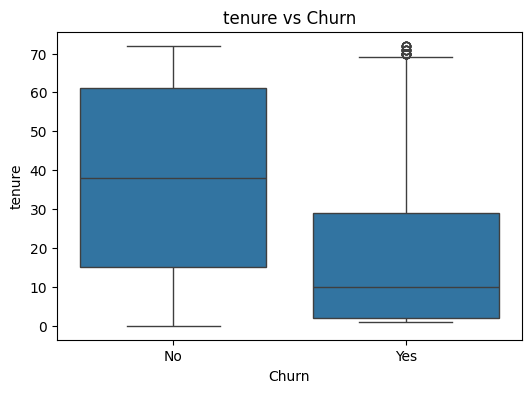

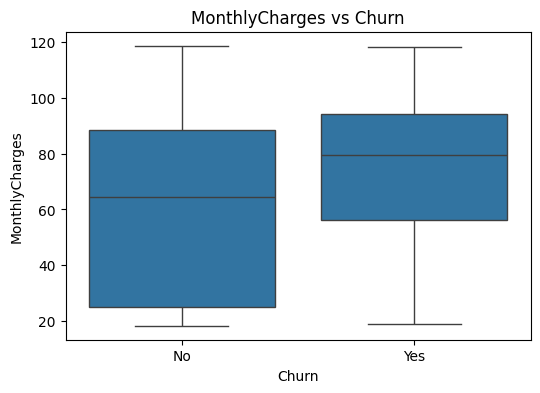

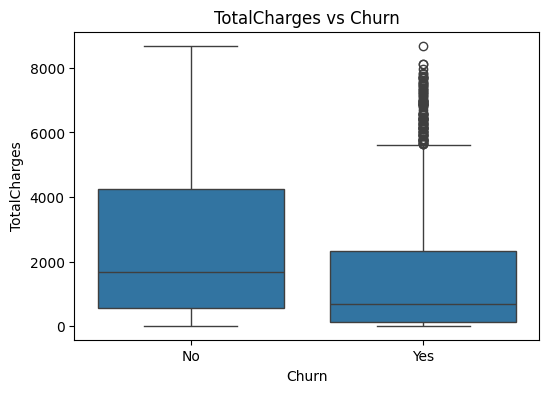

In [354]:
#Step 16
## Numerical features vs Churn
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()


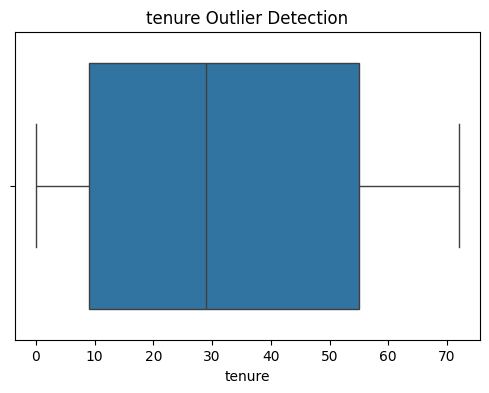

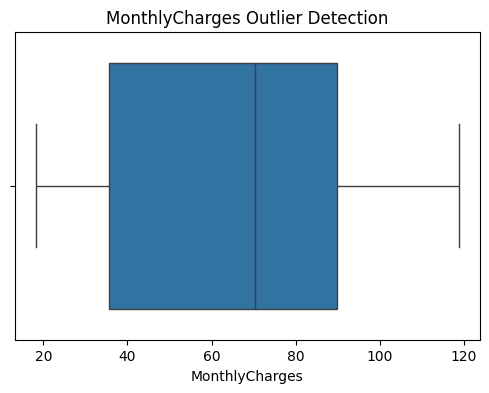

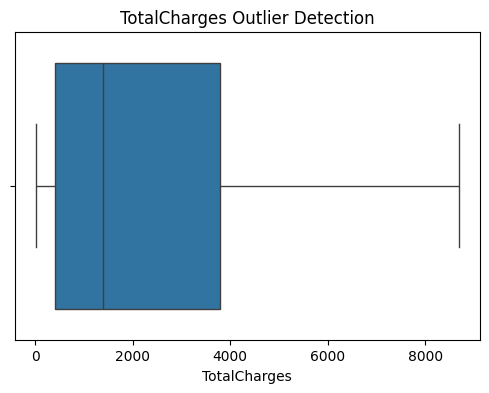

In [355]:
#Step 17
#Outlier Detection
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Outlier Detection')
    plt.show()

In [356]:
#Step 18
#Outliers by Numbers
for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


In [357]:
#Step 19
#Verify Numerical Features
print(numerical_features)


['tenure', 'MonthlyCharges', 'TotalCharges']


In [358]:
#Step 20
#Separate X and Y
X=df.drop("Churn",axis=1)
Y=df["Churn"]

In [359]:
#Step 21
#Encode Categorical Features
X=pd.get_dummies(X,drop_first=True)
Y=Y.map({"Yes":1,"No":0})
print(X,Y)

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0                 0       1           29.85         29.85        False   
1                 0      34           56.95       1889.50         True   
2                 0       2           53.85        108.15         True   
3                 0      45           42.30       1840.75         True   
4                 0       2           70.70        151.65        False   
...             ...     ...             ...           ...          ...   
7038              0      24           84.80       1990.50         True   
7039              0      72          103.20       7362.90        False   
7040              0      11           29.60        346.45        False   
7041              1       4           74.40        306.60         True   
7042              0      66          105.65       6844.50         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            True           False             False   
1

In [360]:
#Step 22
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [361]:
#Step 23
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [362]:
#Step 24
#Implement Algorithms
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Model
lr = LogisticRegression()
lr.fit(X_train, Y_train)

# Predict
lr_pred = lr.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(Y_test, lr_pred)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Detailed Evaluation
print(classification_report(Y_test, lr_pred))
print(confusion_matrix(Y_test, lr_pred))

Logistic Regression Accuracy: 0.8204
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

[[934 102]
 [151 222]]


In [363]:
#Step 25
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#Train Model
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,Y_train)

#Predict
knn_pred = knn.predict(X_test)

#Accuracy
knn_accuracy = accuracy_score(Y_test, knn_pred)
print(f"KNN Accuracy: {knn_accuracy:.4f}")
# Detailed Evaluation
print(classification_report(Y_test, knn_pred))
print(confusion_matrix(Y_test, knn_pred))


KNN Accuracy: 0.7708
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1036
           1       0.57      0.52      0.55       373

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.70      1409
weighted avg       0.76      0.77      0.77      1409

[[892 144]
 [179 194]]


In [364]:
#Step 26
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

#Train Model
GN=GaussianNB()
GN.fit(X_train,Y_train)

#Predict
GN_pred = GN.predict(X_test)

#Accuracy
GN_accuracy = accuracy_score(Y_test, GN_pred)
print(f"Naive Bayes Accuracy: {GN_accuracy:.4f}")
# Detailed Evaluation
print(classification_report(Y_test, GN_pred))
print(confusion_matrix(Y_test, GN_pred))

Naive Bayes Accuracy: 0.6657
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      1036
           1       0.44      0.89      0.59       373

    accuracy                           0.67      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.67      0.68      1409

[[605 431]
 [ 40 333]]


In [365]:
#Step 27
#SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#Train Model
sv=SVC(kernel='linear')
sv.fit(X_train,Y_train)

#Predict
sv_pred = sv.predict(X_test)

#Accuracy
sv_accuracy = accuracy_score(Y_test, sv_pred)
print(f"SVM Accuracy: {sv_accuracy:.4f}")
# Detailed Evaluation
print(classification_report(Y_test, sv_pred))
print(confusion_matrix(Y_test, sv_pred))


SVM Accuracy: 0.8211
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

[[935 101]
 [151 222]]


In [366]:
#Step 28
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#Train Model
dt=DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train,Y_train)

#Predict
dt_pred = dt.predict(X_test)

#Accuracy
dt_accuracy = accuracy_score(Y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
 #Detailed Evaluation
print(classification_report(Y_test, dt_pred))
print(confusion_matrix(Y_test, dt_pred))



Decision Tree Accuracy: 0.8062
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409

[[964  72]
 [201 172]]


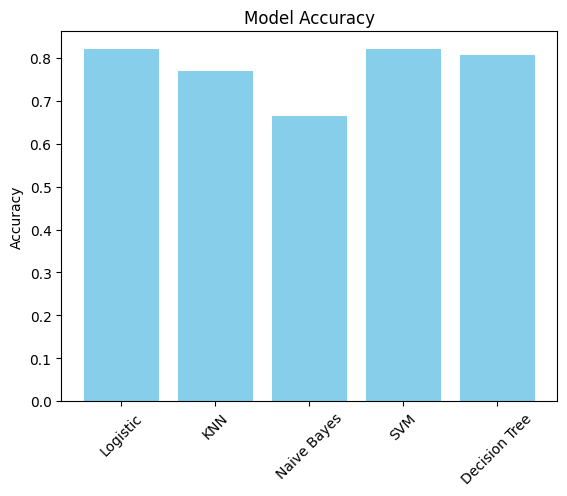


MODEL RANKING:
SVM: 0.8211
Logistic: 0.8204
Decision Tree: 0.8062
KNN: 0.7708
Naive Bayes: 0.6657


In [367]:
#Step 29
#Compare All Models
models = ['Logistic', 'KNN', 'Naive Bayes','SVM','Decision Tree']
accuracies = [0.8204,0.7708,0.6657,0.8211,0.8062]

plt.bar(models, accuracies, color='skyblue')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

# Ranking
print("\nMODEL RANKING:")
for model, acc in sorted(zip(models, accuracies), key=lambda x: x[1], reverse=True):
    print(f"{model}: {acc:.4f}")


#Ensemble Techniques

In [368]:
#Step 30
# Voting Ensemble
#Collection Wisdom of all Models
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

voting_clf = VotingClassifier(estimators=[
    ('lr', lr),
    ('knn', knn),
    ('dt', dt),
    ('gn', GN),
    ('sv', sv)
], voting='hard')

voting_clf.fit(X_train, Y_train)
voting_pred = voting_clf.predict(X_test)

voting_accuracy = accuracy_score(Y_test, voting_pred)
print(f"Voting Ensemble Accuracy: {voting_accuracy:.4f}")

Voting Ensemble Accuracy: 0.8226


In [369]:
#Step 31
#Bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging_clf.fit(X_train, Y_train)
bagging_pred = bagging_clf.predict(X_test)

bagging_accuracy = accuracy_score(Y_test, bagging_pred)
print(f"Bagging Accuracy: {bagging_accuracy:.4f}")

Bagging Accuracy: 0.7750


In [370]:
#Step 32
# AdaBoost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

ada_clf = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

ada_clf.fit(X_train, Y_train)
ada_pred = ada_clf.predict(X_test)

ada_accuracy = accuracy_score(Y_test, ada_pred)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")


AdaBoost Accuracy: 0.8141


In [371]:
#Step 33
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_clf.fit(X_train, Y_train)
gb_pred = gb_clf.predict(X_test)

gb_accuracy = accuracy_score(Y_test, gb_pred)
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")

Gradient Boosting Accuracy: 0.8119


In [372]:
#Step 34
# Stacking
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn),
        ('dt', dt),
        ('sv', sv)
    ],
    final_estimator=LogisticRegression()
)

stacking_clf.fit(X_train, Y_train)
stacking_pred = stacking_clf.predict(X_test)

stacking_accuracy = accuracy_score(Y_test, stacking_pred)
print(f"Stacking Accuracy: {stacking_accuracy:.4f}")

Stacking Accuracy: 0.8219


               Model  Accuracy
0             Voting  0.822569
4           Stacking  0.821859
2           AdaBoost  0.814053
3  Gradient Boosting  0.811923
1            Bagging  0.775018


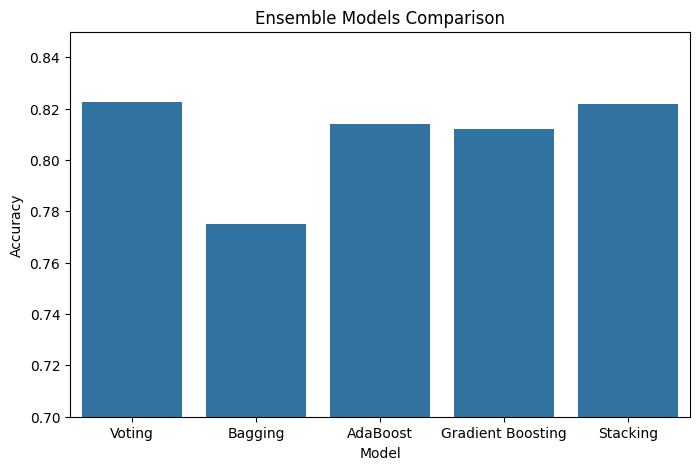

In [373]:
#Step 35
# Compare All Ensemble Models
ensemble_results = {
    'Voting': voting_accuracy,
    'Bagging': bagging_accuracy,
    'AdaBoost': ada_accuracy,
    'Gradient Boosting': gb_accuracy,
    'Stacking': stacking_accuracy
}

results_df = pd.DataFrame(list(ensemble_results.items()), columns=['Model', 'Accuracy'])
print(results_df.sort_values('Accuracy', ascending=False))

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Ensemble Models Comparison')
plt.ylim(0.7, 0.85)
plt.show()

In [374]:
#Step 36
#Insights
# Voting Ensemble achieved the best accuracy (0.8226) because it combines 5
#diverse algorithms — Logistic Regression, KNN, Decision Tree, Naive Bayes, and SVM
# Stacking came in close second (0.8219), also benefiting from model diversity combined with a meta learner
# Bagging had the lowest accuracy (0.7750) since it repeats a single weak algorithm, Decision Tree, which limits improvement
# AdaBoost (0.8141) and Gradient Boosting (0.8119) are both boosting methods, but being based on a single type of base learner
# kept them behind Voting and Stacking
# Core takeaway: combining diverse algorithms generally outperforms repeating a single algorithm multiple times
# Voting Ensemble and Stacking emerge as the best candidates for the final model on this dataset

In [375]:
#Step 37
# GridSearchCV Tuning - Gradient Boosting
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [376]:
#Step 38
# Best Parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best Cross Validation Accuracy: 0.8010286823819033


In [377]:
#Step 39
# Retrain with Best Params
best_gb = grid_search.best_estimator_

best_gb.fit(X_train, Y_train)
best_gb_pred = best_gb.predict(X_test)

best_gb_accuracy = accuracy_score(Y_test, best_gb_pred)
print(f"Tuned Gradient Boosting Accuracy: {best_gb_accuracy:.4f}")

Tuned Gradient Boosting Accuracy: 0.8126


In [378]:
#Step 40
# Final Model Selection
final_results = {
    'Voting': voting_accuracy,
    'Bagging': bagging_accuracy,
    'AdaBoost': ada_accuracy,
    'Gradient Boosting': gb_accuracy,
    'Stacking': stacking_accuracy,
    'Tuned Gradient Boosting': best_gb_accuracy
}

final_df = pd.DataFrame(list(final_results.items()), columns=['Model', 'Accuracy'])
final_df = final_df.sort_values('Accuracy', ascending=False)
print(final_df)

best_model_name = final_df.iloc[0]['Model']
print(f"\nFinal Selected Model: {best_model_name}")

                     Model  Accuracy
0                   Voting  0.822569
4                 Stacking  0.821859
2                 AdaBoost  0.814053
5  Tuned Gradient Boosting  0.812633
3        Gradient Boosting  0.811923
1                  Bagging  0.775018

Final Selected Model: Voting


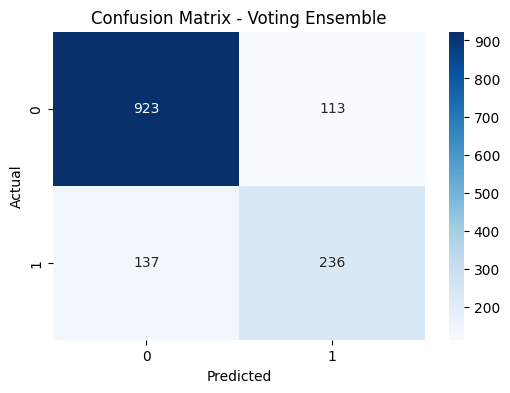

In [379]:
#Step 41
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, voting_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Voting Ensemble')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [380]:
#Step 42
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(Y_test, voting_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1036
           1       0.68      0.63      0.65       373

    accuracy                           0.82      1409
   macro avg       0.77      0.76      0.77      1409
weighted avg       0.82      0.82      0.82      1409



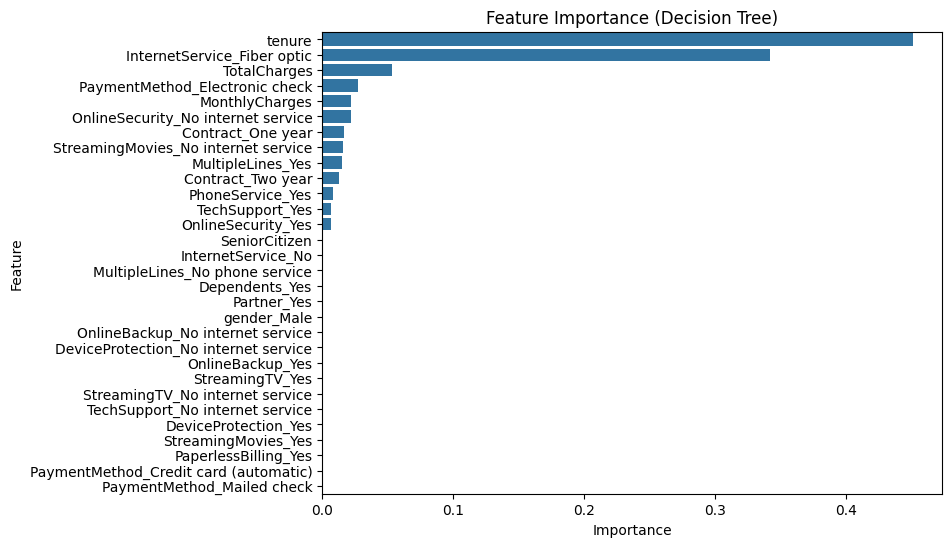

In [381]:
#Step 43
# Feature Importance (using Decision Tree)
importances = dt.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Feature Importance (Decision Tree)')
plt.show()

In [382]:
#Step 44
# Predictions on New Data
new_customer = X_test[0].reshape(1, -1)  # numpy array indexing

prediction = voting_clf.predict(new_customer)
result = "Churn" if prediction[0] == 1 else "No Churn"
print(f"Prediction for new customer: {result}")

Prediction for new customer: Churn


In [383]:
#Step 45
#Key Insights
# Contract type, tenure, and monthly charges were among the strongest predictors of churn
#Customers with month to month contracts showed significantly higher churn rates compared to those on longer contracts
#Customers without internet service showed the lowest churn rate
#Ensemble methods that combined diverse algorithms (Voting, Stacking) outperformed ensembles based on a single algorithm
# (Bagging, Boosting)
#The final model correctly identifies churn risk in approximately 82% of cases, though some churned customers were
# still missed (false negatives), highlighting an area for future improvement

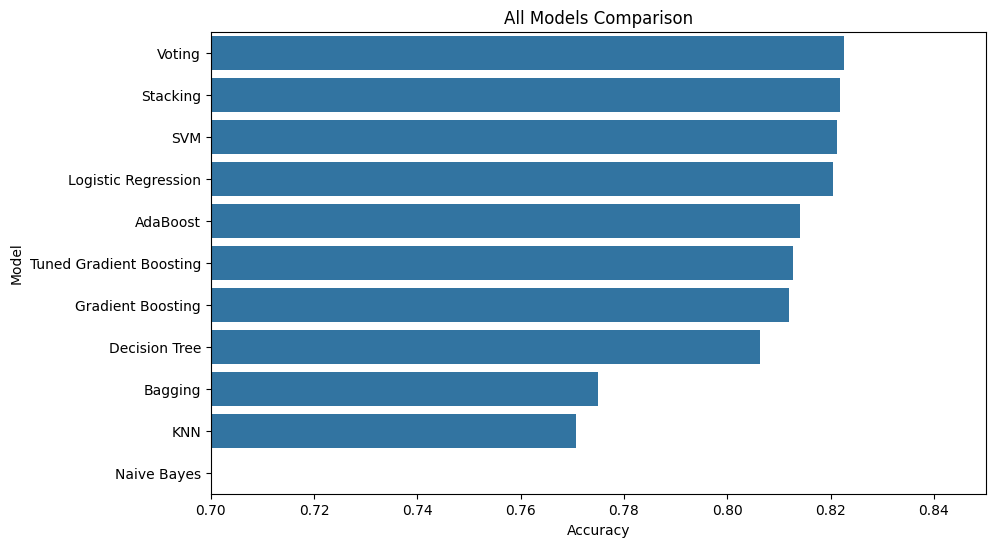

In [384]:
all_results = {
    'Logistic Regression': lr_accuracy,
    'KNN': knn_accuracy,
    'Decision Tree': dt_accuracy,
    'Naive Bayes': GN_accuracy,
    'SVM': sv_accuracy,
    'Voting': voting_accuracy,
    'Bagging': bagging_accuracy,
    'AdaBoost': ada_accuracy,
    'Gradient Boosting': gb_accuracy,
    'Stacking': stacking_accuracy,
    'Tuned Gradient Boosting': best_gb_accuracy
}

all_df = pd.DataFrame(list(all_results.items()), columns=['Model', 'Accuracy'])
all_df = all_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Accuracy', y='Model', data=all_df)
plt.title('All Models Comparison')
plt.xlim(0.7, 0.85)
plt.show()

#**Conclusion**

This project built a customer churn prediction system by comparing individual machine learning algorithms with ensemble techniques including Voting, Bagging, Boosting, and Stacking. The Voting Ensemble delivered the best accuracy at 82.26%, proving that combining diverse models outperforms relying on a single algorithm. The project provided hands on experience in the complete ML workflow, from data preprocessing to model evaluation, and reinforced the practical value of ensemble learning in real world classification problems.